在训练过程中加上更多的控制机制
1. 训练过程可视化
2. 早停
3. 训练中保存/保存最好的模型

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import sklearn
import pandas as pd
import sys
from tqdm.notebook import tqdm
import torch
import torch.nn as nn
from torchvision import datasets
from torchvision import transforms
import os

print(sys.version_info)
for module in mpl, np, pd, sklearn, torch:
    print(module.__name__, module.__version__)
    
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)

sys.version_info(major=3, minor=12, micro=3, releaselevel='final', serial=0)
matplotlib 3.10.8
numpy 2.4.3
pandas 3.0.1
sklearn 1.8.0
torch 2.10.0+cu128
cuda:0


In [2]:
# 定义数据集的变换
transform = transforms.Compose([
    transforms.ToTensor(),
    # 转换成Tensor, 并归一化
    # transforms.Normalize(mean, std)
])
train_ds = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

In [3]:
#计算均值和方差
def cal_mean_std(ds):
    mean = 0.
    std = 0.
    for image_input, _ in ds:  
        # 遍历每张图片, image.shape=[1,28,28]
        mean += image_input.mean(dim=(1, 2))  
        # 计算每张图片的均值, dim=(1, 2)表示每张图片的宽高共同求均值
        std += image_input.std(dim=(1, 2))
    mean /= len(ds)
    std /= len(ds)
    return mean, std
    # 单通道的图, mean结果是0维张量 
    # 如果是多通道的图, mean是1维张量, 传入Normalize时最好使用tolist

mean_train, std_train = cal_mean_std(train_ds)
print(cal_mean_std(train_ds))

(tensor([0.2860]), tensor([0.3205]))


In [4]:
print(cal_mean_std(train_ds))
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean_train, std_train)
])
# 重新定义变换, 加上标准化
train_ds = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

test_ds = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)

(tensor([0.2860]), tensor([0.3205]))


In [5]:
# 数据加载器, 将其进行分批和其他处理
train_ld = torch.utils.data.DataLoader(train_ds, batch_size=32, shuffle=True)  
#batch_size批大小, shuffle洗牌, 这是为了避免局部最优解
val_ld = torch.utils.data.DataLoader(test_ds, batch_size=32, shuffle=False)
# 验证集不需要打乱

In [6]:
class NeuralNetwork(nn.Module):
    # 继承nn.Module
    def __init__(self):
        super().__init__() 
        # 继承父类的初始化方法, 子类有父类的属性
        self.flatten = nn.Flatten()  
        # 展平层, 将784个像素变成784个特征
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(784, 300),  
            # 全连接层/线性层
            # in_features=784输入特征数, out_features=300输出特征数
            nn.ReLU(), 
            # 激活函数
            nn.Linear(300, 100),
            # 隐藏层神经元数100
            nn.ReLU(), 
            # 激活函数
            nn.Linear(100, 10),
            # 输出层神经元数10, 对应十个标签
        )

    def forward(self, x): 
        # 重写父类的forward, 进行正向计算/前向传播
        # 展平前x.shape是[32, 1, 28, 28]
        x = self.flatten(x)
        # 展平后x.shape是[32, 784]
        logits = self.linear_relu_stack(x)
        # linear_relu_stack使用了Sequential这一封装容器, 自动顺序执行每层计算
        # logits.shape是[32, 10]
        return logits 
        # 没有经过softmax处理的输出, 称为logits
    
network = NeuralNetwork()

# 加入训练过程中的更多控制

TensorBoard可视化

In [7]:
from torch.utils.tensorboard import SummaryWriter


class TensorBoardCallback:
    def __init__(self, log_dir, flush_secs=10):
        """
        Args:
            log_dir (str): dir to write log.
            flush_secs (int, optional): write to dsk each flush_secs seconds. Defaults to 10.
        """
        self.writer = SummaryWriter(log_dir=log_dir, flush_secs=flush_secs) 
        # 实例化SummaryWriter, log_dir是log存放路径, flush_secs是每隔多少秒写入磁盘

    def draw_model(self, model, input_shape):#graphs
        self.writer.add_graph(model, input_to_model=torch.randn(input_shape)) 
        # 画模型图
        
    def add_loss_scalars(self, step, loss, val_loss):
        self.writer.add_scalars(
            main_tag="training/loss", 
            tag_scalar_dict={"loss": loss, "val_loss": val_loss},
            global_step=step,
            ) 
        # 画loss曲线, main_tag是主tag, tag_scalar_dict是子tag, global_step是步数
        
    def add_acc_scalars(self, step, acc, val_acc):
        self.writer.add_scalars(
            main_tag="training/accuracy",
            tag_scalar_dict={"accuracy": acc, "val_accuracy": val_acc},
            global_step=step,
        ) 
        # 画acc曲线, main_tag是主tag, tag_scalar_dict是子tag, global_step是步数
        
    def add_lr_scalars(self, step, learning_rate):
        self.writer.add_scalars(
            main_tag="training/learning_rate",
            tag_scalar_dict={"learning_rate": learning_rate},
            global_step=step,
        ) 
        # 画lr曲线, main_tag是主tag, tag_scalar_dict是子tag, global_step是步数
    
    def __call__(self, step, **kwargs):
        # add loss,把loss, val_loss去掉, 画loss曲线
        loss = kwargs.pop("loss", None)
        val_loss = kwargs.pop("val_loss", None)
        if loss is not None and val_loss is not None:
            self.add_loss_scalars(step, loss, val_loss)
            # 画loss曲线
        # add acc
        acc = kwargs.pop("acc", None)
        val_acc = kwargs.pop("val_acc", None)
        if acc is not None and val_acc is not None:
            self.add_acc_scalars(step, acc, val_acc) 
            # 画acc曲线
        # add lr
        learning_rate = kwargs.pop("lr", None)
        if learning_rate is not None:
            self.add_lr_scalars(step, learning_rate) 
            # 画lr曲线


Save Best  
训练被中断后, 恢复训练时用已有的最好参数开始  
或者为了上线部署

In [8]:
class SaveCheckpointsCallback:
    def __init__(self, save_dir, save_epoch=1, save_step=500, save_best_only=True):
        """
        Save checkpoints each save_epoch epoch. 
        We save checkpoint by epoch in this implementation.
        Usually, training scripts with pytorch evaluating model and save checkpoint by step.

        Args:
            save_dir (str): dir to save checkpoint
            save_epoch (int, optional): the frequency to save checkpoint. Defaults to 1.
            save_best_only (bool, optional): If True, only save the best model or save each model at every epoch.
        """
        self.save_dir = save_dir # 保存路径
        self.save_step = save_step # 保存步数
        self.save_best_only = save_best_only # 是否只保存最好的模型
        self.best_metrics = -1 # 最好的指标, 指标不可能为负数, 所以初始化为-1
        self.save_epoch = save_epoch
        # mkdir
        if not os.path.exists(self.save_dir): 
            # 如果不存在保存路径, 则创建
            os.mkdir(self.save_dir)
        
    def __call__(self, step, state_dict, metric=None):
        if step % self.save_step > 0: 
            # 每隔save_step步保存一次
            return
        
        if self.save_best_only:
            assert metric is not None,'metric is not None' 
            # 必须传入metric
            if metric >= self.best_metrics:
                # save checkpoints
                torch.save(state_dict, os.path.join(self.save_dir, "best.ckpt")) 
                # os.path.join表示路径拼接, 相当于save_dir+"best.ckpt"
                # 保存最好的模型, 覆盖之前的模型
                # 不保存step, 只保存state_dict, 即模型参数, 不保存优化器参数
                self.best_metrics = metric
        else:
            torch.save(state_dict, os.path.join(self.save_dir, f"{step}.ckpt")) 
            # 保存每个step的模型, 不覆盖之前的模型
            # 保存step, 保存state_dict, 即模型参数, 不保存优化器参数

Early Stop

In [9]:
class EarlyStopCallback:
    def __init__(self, patience=5, min_delta=0.01):
        """

        Args:
            patience (int, optional): Number of epochs with no improvement after which training will be stopped. Defaults to 5.
            min_delta (float, optional): Minimum change in the monitored quantity to qualify as an improvement, i.e. an absolute 
                change of less than min_delta, will count as no improvement. Defaults to 0.01.
        """
        self.patience = patience 
        # 多少个step没有提升min_delta就停止训练
        self.min_delta = min_delta 
        # 最小的提升幅度
        self.best_metric = -1
        self.counter = 0 
        # 计数器, 记录多少个step没有提升
        
    def __call__(self, metric):
        if metric >= self.best_metric + self.min_delta:
            self.best_metric = metric
            # 将当前算子作为最佳算子
            self.counter = 0
        else: 
            self.counter += 1
            # 假如这一步没有更优, 则计数器加一
            
    @property 
    # property装饰器指将方法变成属性
    def early_stop(self):
        return self.counter >= self.patience


# 训练

In [10]:
# 1. 定义损失函数
loss_fct = nn.CrossEntropyLoss()
# 输出时将logits经过softmax, 和转换为one-hot编码的标签值计算交叉熵损失
# 得到的是标量(0维张量)

# 2. 定义优化器 采用SGD(随机梯度下降, stochastic gradient descent)
opt = torch.optim.SGD(network.parameters(), lr=0.001, momentum=0.9)
# lr学习率, momentum动量

In [11]:
from sklearn.metrics import accuracy_score


# 3.编写评估函数
@torch.no_grad()
# 装饰器, 禁止反向传播, 节省内存
def evaluating(model, dataloader, loss_function):
    loss_list = []
    # 记录损失
    pred_list = []
    # 记录预测
    label_list = []
    # 记录标签
    for data, label in dataloader:
        # 一共10000/32=312个batch
        data = data.to(device)
        # 把tensor放入GPU
        label = label.to(device)
        # 转到GPU
        logits = model(data)
        # 前向计算
        loss = loss_function(logits, label)
        # 使用loss_function计算本batch的损失, 得到的实际上是一个张量
        loss_list.append(loss.item())
        # 记录损失, item把tensor转换为数值, 注意item只能处理0维张量  

        pred = logits.argmax(axis=-1)
        # 验证集预测, argmax返回最大值索引数组
        # logits是一个(32, 10)数组, 求出的pred是一个(32, )数组,
        # 即每个样本使用十个标签概率的最大值的索引作为预测值
        pred_list.extend(pred.cpu().numpy().tolist())
        # numpy()将PyTorch张量转换为NumPy数组。只有当张量在CPU上时, 这个转换才是合法的
        label_list.extend(label.cpu().numpy().tolist())

    acc = accuracy_score(label_list, pred_list)
    # 计算准确率
    return np.mean(loss_list), acc

In [12]:
# 训练过程中的控制
# tensorboard 可视化
tensorboard_callback = TensorBoardCallback("runs")
tensorboard_callback.draw_model(network, [1, 28, 28]) #画模型结构图
# save best
save_ckpt_callback = SaveCheckpointsCallback("checkpoints", save_best_only=True)
# early stop
early_stop_callback = EarlyStopCallback(patience=5)

In [13]:
# 4.训练

def training(model, train_loader, val_loader, epoch, loss_function,
             optimizer,
             tensorboard=None,
             save_ckpt=None,
             early_stop=None,
             eval_step=500):
    """
    训练函数
    :param model: 模型
    :param train_loader: 训练数据集
    :param val_loader: 验证数据集
    :param epoch: 训练轮数
    :param loss_function: 损失函数
    :param optimizer: 优化器
    :param tensorboard: 可视化回调函数
    :param save_ckpt: 保存回调函数
    :param early_stop: 早停回调函数
    :param eval_step: 每训练多少batch对验证集进行评估
    :return: dict
    """
    record_dict = {
        "train": [],
        "val": []
    }
    # 存储训练集和测试集的损失和准确率
    global_step = 0
    # 记录总步数, 在进度条中使用
    model.train()
    # 进入训练模式
    # 对于一些特定层很重要：
    # Dropout → 在训练阶段才会随机丢弃神经元
    # BatchNorm → 使用 batch 的均值和方差
    with (tqdm(total=epoch * len(train_loader)) as pbar): 
        # with是上下文管理器, 保证进度条结束后自动关闭
        # 进度条一共 len(train_loader)*epoch 步
        for epoch_id in range(epoch): 
            # 训练epoch次
            for data, label in train_loader: 
                # 每次迭代得到一个batch
                # 执行次数是60000/32=1875
                data = data.to(device) 
                # datas尺寸是[batch_size,1,28,28], 转到GPU
                label = label.to(device) 
                # labels尺寸是[batch_size], 转到GPU
                optimizer.zero_grad()
                # 梯度清空, PyTorch会累加梯度, 要避免上一batch的梯度影响后面
                logits = model(data)
                # 正向计算, 得到未经过softmax的输出
                loss = loss_function(logits, label)
                # 计算损失
                loss.backward()
                # 梯度回传, loss.backward()会计算梯度, loss对模型参数(权重和偏置)求导
                optimizer.step()
                # 调整优化器, 改变学习率(如果使用了学习率调度器), 更新模型参数和一些其他值
                # 梯度计算并存储在模型参数的 .grad 属性中
                # 优化器使用这些存储的梯度来更新模型参数

                pred = logits.argmax(axis=-1) 
                # 对训练集预测
                acc = accuracy_score(label.cpu().numpy(), pred.cpu().numpy()) 
                # 每个batch计算准确率
                loss = loss.cpu().item()
                # loss这一0维张量转换为数值
                record_dict["train"].append({
                    "loss": loss, "acc": acc, "step": global_step
                }) 
                # 记录训练集信息, 每一步的损失, 准确率, 步数
                
                if global_step % eval_step == 0:
                    model.eval() 
                    # 进入评估模式
                    # Dropout 停用
                    # BatchNorm 使用训练时统计值
                    val_loss, val_acc = evaluating(model, val_loader, 
                                                   loss_function)
                    record_dict["val"].append({
                        "loss": val_loss, "acc": val_acc, "step": global_step
                    })
                    model.train() 
                    # 进入训练模式
                    
                    # 1. 使用tensorboard可视化
                    if tensorboard is not None:
                        tensorboard(
                            global_step, 
                            loss=loss, val_loss=val_loss,
                            acc=acc, val_acc=val_acc,
                            lr=optimizer.param_groups[0]["lr"], # 取出当前学习率
                            )
                    
                    # 2. 保存模型权重save model checkpoint
                    if save_ckpt is not None:
                        save_ckpt(global_step, model.state_dict(), metric=val_acc) 
                        # 保存最好的模型, 覆盖之前的模型
                        # 保存step, 保存state_dict,通过metric判断是否保存最好的模型

                    # 3. 早停Early Stop
                    if early_stop is not None:
                        early_stop(val_acc) 
                        # 验证集准确率不再提升, 则停止训练
                        if early_stop.early_stop:
                            # 注意之前有property装饰器, 将方法作为属性计算
                            # 属性的值就是方法的返回值
                            print(f"Early stop at epoch {epoch_id} / global_step {global_step}")
                            return record_dict

                global_step += 1 
                # 全局步数加1
                pbar.update(1) 
                # 更新进度条
                pbar.set_postfix({"epoch": epoch_id}) 
                # 设置进度条显示信息
        
    return record_dict

In [14]:
network = network.to(device)
record=training(network, train_ld, val_ld, epoch=100, loss_function=loss_fct, optimizer=opt, tensorboard=tensorboard_callback, save_ckpt=save_ckpt_callback, early_stop=early_stop_callback, eval_step=1000)

  0%|          | 0/187500 [00:00<?, ?it/s]

Early stop at epoch 7 / global_step 14000


Index(['loss', 'acc'], dtype='str')
step
0        0.06250
1000     0.84375
2000     0.87500
3000     0.78125
4000     0.90625
5000     0.87500
6000     0.87500
7000     0.93750
8000     0.90625
9000     0.81250
10000    0.93750
11000    0.96875
12000    0.87500
13000    0.87500
14000    0.96875
Name: acc, dtype: float64
step
0        0.0526
1000     0.7966
2000     0.8246
3000     0.8307
4000     0.8343
5000     0.8494
6000     0.8561
7000     0.8568
8000     0.8590
9000     0.8649
10000    0.8593
11000    0.8704
12000    0.8698
13000    0.8676
14000    0.8740
Name: acc, dtype: float64


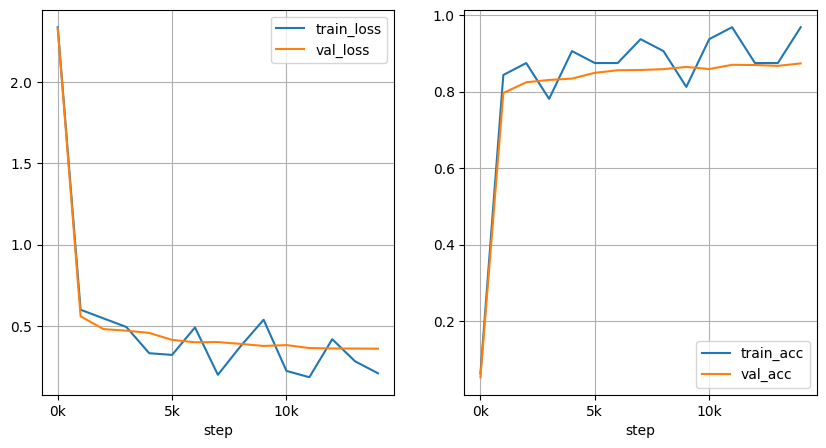

In [15]:
def plot_learning_curves(record_dict, sample_step=1000):
    train_df = pd.DataFrame(record_dict["train"]).set_index("step").iloc[::sample_step]
    # set_index将行索引设置成step, 每隔sample_step取一次
    val_df = pd.DataFrame(record_dict["val"]).set_index("step")
    last_step = train_df.index[-1]
    # 最后一步的步数
    print(train_df.columns)
    print(train_df['acc'])
    print(val_df['acc'])
    
    fig_num = len(train_df.columns)
    fig, axs = plt.subplots(1, fig_num, figsize=(5 * fig_num, 5))
    for idx, item in enumerate(train_df.columns):
        # enumerate同时得到索引和值
        # print(train_df[item].values)
        axs[idx].plot(train_df.index, train_df[item], label=f"train_{item}")
        axs[idx].plot(val_df.index, val_df[item], label=f"val_{item}")
        axs[idx].grid()
        axs[idx].legend()
        axs[idx].set_xticks(range(0, train_df.index[-1], 5000)) 
        axs[idx].set_xticklabels(map(lambda x: f"{int(x/1000)}k", range(0, last_step, 5000)))
        axs[idx].set_xlabel("step")
    
    plt.show()

plot_learning_curves(record)

In [16]:
first_param = next(network.parameters())
first_key, first_value = next(iter(network.state_dict().items()))
print(first_param)
print()
print(first_key, first_value)

Parameter containing:
tensor([[ 0.0013, -0.0027,  0.0330,  ..., -0.0297, -0.0067, -0.0138],
        [ 0.0108, -0.0008,  0.0328,  ..., -0.0288,  0.0167,  0.0003],
        [ 0.0231, -0.0313,  0.0265,  ...,  0.0331,  0.0186, -0.0175],
        ...,
        [-0.0320, -0.0314, -0.0377,  ..., -0.0034, -0.0108, -0.0325],
        [-0.0123,  0.0251,  0.0198,  ..., -0.0159, -0.0114, -0.0176],
        [-0.0212, -0.0054,  0.0387,  ...,  0.0344,  0.0252, -0.0241]],
       device='cuda:0', requires_grad=True)

linear_relu_stack.0.weight tensor([[ 0.0013, -0.0027,  0.0330,  ..., -0.0297, -0.0067, -0.0138],
        [ 0.0108, -0.0008,  0.0328,  ..., -0.0288,  0.0167,  0.0003],
        [ 0.0231, -0.0313,  0.0265,  ...,  0.0331,  0.0186, -0.0175],
        ...,
        [-0.0320, -0.0314, -0.0377,  ..., -0.0034, -0.0108, -0.0325],
        [-0.0123,  0.0251,  0.0198,  ..., -0.0159, -0.0114, -0.0176],
        [-0.0212, -0.0054,  0.0387,  ...,  0.0344,  0.0252, -0.0241]],
       device='cuda:0')


# 上线

In [17]:
network = NeuralNetwork()  
# 模拟上线
network = network.to(device)
# 模型保存有两种情况, 
# 一种是模型结构和模型参数都保存, 一种是只保存模型参数(即只保存state.dict)
# load checkpoints
network.load_state_dict(torch.load("checkpoints/best.ckpt", weights_only=True, map_location="cpu"))
# 这里weight_only=False也行, 因为本来就只有参数
network.eval()
final_loss, final_acc = evaluating(network, val_ld, loss_fct)
# 上线之后只进行前向计算
print(f"final loss:     {final_loss:.4f}\nfinal accuracy: {final_acc:.4f}")

final loss:     0.3609
final accuracy: 0.8740
